# Group DRO — Waterbirds (Sagawa et al., 2020)

Implémentation de **Distributionally Robust Neural Networks for Group Shifts** sur le dataset Waterbirds.

Hyperparamètres alignés sur la paper :
- ResNet-50 pré-entraîné ImageNet
- SGD, lr=1e-5, momentum=0.9
- λ (weight decay) = 1.0
- Group adjustments C=2
- Pas d'augmentation
- 300 époques, batch_size=128

## 1. Setup & téléchargement du dataset

In [1]:
import os
import subprocess

if not os.path.exists('data/metadata.csv'):
    print("Téléchargement du dataset Waterbirds...")
    !wget -q --show-progress https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz
    !tar -xzf waterbird_complete95_forest2water2.tar.gz
    !mv waterbird_complete95_forest2water2 data
    !rm waterbird_complete95_forest2water2.tar.gz
    print("Dataset extrait dans ./data/")
else:
    print("Dataset déjà présent.")

Téléchargement du dataset Waterbirds...
waterbird_complete9 100%[===================>] 467.01M  5.00MB/s    in 89s     
Dataset extrait dans ./data/


## 2. Imports & hyperparamètres

In [2]:
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torchvision.models import resnet50
from torch import stack, tensor
from PIL import Image
import torchvision.transforms as transforms
import torch
import pandas as pd
import numpy as np
import os

# Hyperparamètres (Sagawa et al., 2020 — Waterbirds)
weight_decay = 1.0        # λ = 1.0 (Section 3.2)
n_epoch = 300
batch_size = 128
dro_step = 0.01           # η_q pour mise à jour de q
group_adj_C = 2           # Group adjustments C (eq. 5, Figure 3)
lr = 0.00001              # lr = 1e-5 avec strong L2 (Appendix C.2)

criterion = torch.nn.CrossEntropyLoss(reduction='none')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 3. Dataset

In [3]:
labels = ['landbird/land', 'landbird/water', 'waterbird/land', 'waterbird/water']

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class WaterbirdsDataset(Dataset):
    def __init__(self, indices, y_array, group_array, filename_array):
        self.indices = indices
        self.images = []
        self.labels = []
        self.groups = []

        print(f"Préchargement de {len(indices)} images")
        for idx in tqdm(indices):
            img = Image.open(os.path.join('data', filename_array[idx])).convert('RGB')
            self.images.append(transform(img))
            self.labels.append(int(y_array[idx]))
            self.groups.append(int(group_array[idx]))
        self.images = stack(self.images)
        self.labels = tensor(self.labels)
        self.groups = tensor(self.groups)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        return self.images[i], self.labels[i], self.groups[i]


def load_dataset():
    metadata = pd.read_csv('data/metadata.csv')
    y_array = metadata['y'].values
    place_array = metadata['place'].values
    group_array = (y_array * 2 + place_array).astype(int)
    filename_array = metadata['img_filename'].values
    split_array = metadata['split'].values

    train_idx = np.where(split_array == 0)[0]
    val_idx = np.where(split_array == 1)[0]
    test_idx = np.where(split_array == 2)[0]

    train_dataset = WaterbirdsDataset(train_idx, y_array, group_array, filename_array)
    val_dataset = WaterbirdsDataset(val_idx, y_array, group_array, filename_array)
    test_dataset = WaterbirdsDataset(test_idx, y_array, group_array, filename_array)

    return train_dataset, val_dataset, test_dataset

In [4]:
train_dataset, val_dataset, test_dataset = load_dataset()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

group_counts = torch.bincount(train_dataset.groups, minlength=4).float()
print(f"\nGroup counts (train): {group_counts.tolist()}")
for i, (label, count) in enumerate(zip(labels, group_counts)):
    print(f"  g{i} ({label}): {int(count)}")

Préchargement de 4795 images


100%|██████████| 4795/4795 [00:08<00:00, 587.53it/s]


Préchargement de 1199 images


100%|██████████| 1199/1199 [00:01<00:00, 642.93it/s]


Préchargement de 5794 images


100%|██████████| 5794/5794 [00:09<00:00, 630.73it/s]



Group counts (train): [3498.0, 184.0, 56.0, 1057.0]
  g0 (landbird/land): 3498
  g1 (landbird/water): 184
  g2 (waterbird/land): 56
  g3 (waterbird/water): 1057


## 4. Modèle & optimiseur

In [5]:
model = resnet50(weights=None)
state_dict = torch.hub.load_state_dict_from_url(
    'https://download.pytorch.org/models/resnet50-19c8e357.pth'
)
model.load_state_dict(state_dict)
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model = model.to(device)

optimizer = SGD(model.parameters(), lr=lr, momentum=0.9)

print(f"Modèle chargé sur {device}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


Modèle chargé sur cuda
Params: 23,512,130


## 5. Fonctions train / eval

In [6]:
def train_epoch(data_loader, model, optimizer, q, group_counts, device):
    model.train()
    total_loss_per_group = torch.zeros(4).to(device)
    total_correct_per_group = torch.zeros(4).to(device)
    total_count_per_group = torch.zeros(4).to(device)

    adjustments = group_adj_C / torch.sqrt(group_counts).to(device)

    for x, y, group in tqdm(data_loader, leave=False):
        x, y, group = x.to(device), y.to(device), group.to(device)

        optimizer.zero_grad()
        output = model(x)

        loss = criterion(output, y)
        predictions = output.argmax(dim=1)

        loss_per_group = torch.zeros(4).to(device)
        for group_index in range(4):
            mask = (group == group_index)
            if mask.sum() > 0:
                loss_per_group[group_index] = loss[mask].mean()
                total_loss_per_group[group_index] += loss[mask].sum()
                total_correct_per_group[group_index] += (predictions[mask] == y[mask]).sum()
                total_count_per_group[group_index] += mask.sum()

        adjusted_loss = loss_per_group + adjustments
        q = q.detach() * torch.exp(dro_step * adjusted_loss.detach())
        q = q / q.sum()

        loss_final = (q * loss_per_group).sum()
        l2 = sum(p.pow(2).sum() for name, p in model.named_parameters() if 'bn' not in name and 'bias' not in name)
        loss_final = loss_final + weight_decay * l2

        loss_final.backward()
        optimizer.step()

    avg_loss = (total_loss_per_group / total_count_per_group.clamp(min=1)).tolist()
    avg_acc = (total_correct_per_group / total_count_per_group.clamp(min=1)).tolist()

    return q, avg_loss, avg_acc


def eval_epoch(data_loader, model, device):
    model.eval()
    total_loss_per_group = torch.zeros(4).to(device)
    total_correct_per_group = torch.zeros(4).to(device)
    total_count_per_group = torch.zeros(4).to(device)

    with torch.no_grad():
        for x, y, group in tqdm(data_loader, leave=False):
            x, y, group = x.to(device), y.to(device), group.to(device)

            output = model(x)
            loss = criterion(output, y)
            predictions = output.argmax(dim=1)

            for group_index in range(4):
                mask = (group == group_index)
                if mask.sum() > 0:
                    total_loss_per_group[group_index] += loss[mask].sum()
                    total_correct_per_group[group_index] += (predictions[mask] == y[mask]).sum()
                    total_count_per_group[group_index] += mask.sum()

    avg_loss = (total_loss_per_group / total_count_per_group.clamp(min=1)).tolist()
    avg_acc = (total_correct_per_group / total_count_per_group.clamp(min=1)).tolist()

    return avg_loss, avg_acc


def log_metrics(label, n, avg_loss, avg_acc):
    print(f"  {label:5s} | " +
          " | ".join([f"g{i}: {avg_acc[i]:.4f}" for i in range(4)]) +
          f" | avg: {sum(avg_acc)/4:.4f} | worst: {min(avg_acc):.4f}")

## 6. Boucle d'entraînement

In [7]:
os.makedirs('./logs', exist_ok=True)

q = (torch.ones(4) / 4).to(device)
best_worst_val_acc = 0
history = {'train_acc': [], 'val_acc': [], 'test_acc': [],
           'train_worst': [], 'val_worst': [], 'test_worst': []}

for epoch in range(n_epoch):
    print(f"\nEpoch {epoch}/{n_epoch}")

    # Train
    q, train_loss, train_acc = train_epoch(train_loader, model, optimizer, q, group_counts, device)
    log_metrics("Train", epoch, train_loss, train_acc)
    print(f"  q     | " + " | ".join([f"g{i}: {q[i]:.4f}" for i in range(4)]))

    torch.cuda.empty_cache()

    # Validation
    val_loss, val_acc = eval_epoch(val_loader, model, device)
    log_metrics("Val", epoch, val_loss, val_acc)

    torch.cuda.empty_cache()

    # Test
    test_loss, test_acc = eval_epoch(test_loader, model, device)
    log_metrics("Test", epoch, test_loss, test_acc)

    torch.cuda.empty_cache()

    # Historique
    history['train_acc'].append(sum(train_acc) / 4)
    history['val_acc'].append(sum(val_acc) / 4)
    history['test_acc'].append(sum(test_acc) / 4)
    history['train_worst'].append(min(train_acc))
    history['val_worst'].append(min(val_acc))
    history['test_worst'].append(min(test_acc))

    # Best model (sur worst-group VAL accuracy)
    worst_val_acc = min(val_acc)
    if worst_val_acc > best_worst_val_acc:
        best_worst_val_acc = worst_val_acc
        torch.save(model.state_dict(), './logs/best_model.pth')
        print(f"  >>> New best worst-group val acc: {worst_val_acc:.4f}")

    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f'./logs/model_epoch_{epoch + 1}.pth')

print(f"\nBest worst-group val accuracy: {best_worst_val_acc:.4f}")


Epoch 0/300


  Train | g0: 0.4417 | g1: 0.2500 | g2: 0.6964 | g3: 0.9007 | avg: 0.5722 | worst: 0.2500
  q     | g0: 0.2493 | g1: 0.2685 | g2: 0.2481 | g3: 0.2342


  Val   | g0: 0.6124 | g1: 0.3476 | g2: 0.6015 | g3: 0.8346 | avg: 0.5990 | worst: 0.3476


  Test  | g0: 0.6373 | g1: 0.4089 | g2: 0.6340 | g3: 0.8474 | avg: 0.6319 | worst: 0.4089
  >>> New best worst-group val acc: 0.3476

Epoch 1/300


  Train | g0: 0.7304 | g1: 0.5598 | g2: 0.5536 | g3: 0.7105 | avg: 0.6386 | worst: 0.5536
  q     | g0: 0.2401 | g1: 0.2777 | g2: 0.2534 | g3: 0.2288


...

  Val   | g0: 0.9829 | g1: 0.9142 | g2: 0.6241 | g3: 0.7895 | avg: 0.8276 | worst: 0.6241


  Test  | g0: 0.9809 | g1: 0.9144 | g2: 0.6604 | g3: 0.8178 | avg: 0.8434 | worst: 0.6604

Epoch 299/300


  Train | g0: 0.9977 | g1: 1.0000 | g2: 1.0000 | g3: 0.9811 | avg: 0.9947 | worst: 0.9811
  q     | g0: 0.0527 | g1: 0.0148 | g2: 0.9168 | g3: 0.0156


  Val   | g0: 0.9829 | g1: 0.9077 | g2: 0.6241 | g3: 0.8271 | avg: 0.8354 | worst: 0.6241


  Test  | g0: 0.9774 | g1: 0.9038 | g2: 0.6760 | g3: 0.8255 | avg: 0.8457 | worst: 0.6760

Best worst-group val accuracy: 0.8872


## 7. Visualisation des résultats

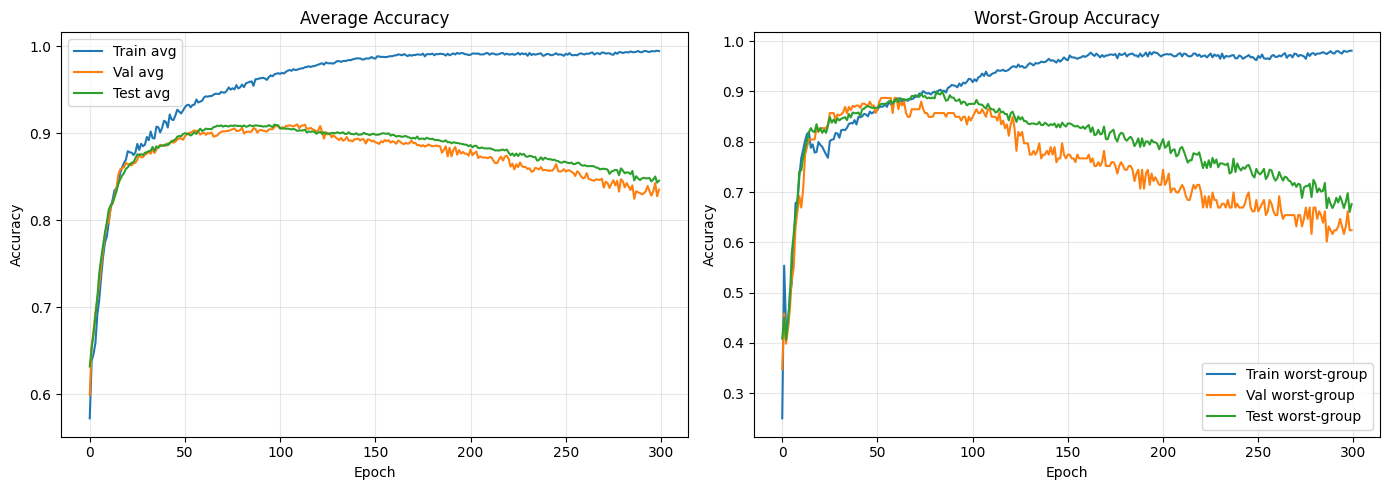

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(len(history['train_acc']))

# Average accuracy
ax = axes[0]
ax.plot(epochs, history['train_acc'], label='Train avg')
ax.plot(epochs, history['val_acc'], label='Val avg')
ax.plot(epochs, history['test_acc'], label='Test avg')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Average Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Worst-group accuracy
ax = axes[1]
ax.plot(epochs, history['train_worst'], label='Train worst-group')
ax.plot(epochs, history['val_worst'], label='Val worst-group')
ax.plot(epochs, history['test_worst'], label='Test worst-group')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Worst-Group Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./logs/training_curves.png', dpi=150)
plt.show()

## 8. Évaluation du meilleur modèle

In [9]:
# Charger le meilleur modèle et évaluer sur le test set
model.load_state_dict(torch.load('./logs/best_model.pth'))
test_loss, test_acc = eval_epoch(test_loader, model, device)

print("=== Best model (selected on worst-group val acc) ===")
print(f"  Test accuracy per group:")
for i, label in enumerate(labels):
    print(f"    g{i} ({label:20s}): {test_acc[i]:.4f}")
print(f"  Average test accuracy:    {sum(test_acc)/4:.4f}")
print(f"  Worst-group test accuracy: {min(test_acc):.4f}")
print(f"\n  Paper target: ~90.5% worst-group (with C=2, lambda=1.0)")

=== Best model (selected on worst-group val acc) ===
  Test accuracy per group:
    g0 (landbird/land       ): 0.8918
    g1 (landbird/water      ): 0.9211
    g2 (waterbird/land      ): 0.9081
    g3 (waterbird/water     ): 0.8754
  Average test accuracy:    0.8991
  Worst-group test accuracy: 0.8754

  Paper target: ~90.5% worst-group (with C=2, lambda=1.0)
